# Norway vs Senegal match prediction (2026-06-22)

Predicts Norway's second World Cup group match with the project's two-model core:

* **Logistic regression** — clean W/D/L probabilities
* **Poisson** — football specific scoreline probabilities (expected goals to scoreline grid).

**Evidence is current as of matchday 1** (2026-06-16): the group's opening results
— *Iraq 1–4 Norway* and *France 3–1 Senegal* — have been added to `matches.csv`,
`elo_ratings.csv` (post-match Elo, eloratings.net World Cup formula) and
`flashscore_stats.csv`, so this prediction reflects how both teams started the tournament.

## 1. Setup

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd

# Make the project importable whether this runs from notebooks/ or the project root.
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

from scipy.stats import poisson

from src.data_collection import build_inputs
from src.preprocessing import load_data as L
from src.features import build_features as F
from src.models import logistic_model as LM
from src.models import poisson_model as P
from src.models.logistic_model import proba_frame
from src.utils.config import FIXTURES, RESULT_CLASSES

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## 2. Build dataset

The Norway vs Senegal fixture is `FIXTURES[1]`.

In [2]:
build_inputs.build_all(force=False)

matches = L.load_matches()
flashscore = L.repair_flashscore(L.load_flashscore(), matches)
fifa = L.load_fifa()
elo = L.load_elo()

persp_feat, model_dataset, all_team_dataset, fixture_dataset = F.engineer(
    matches, elo, fifa, flashscore, FIXTURES)

print("fixtures available:", sorted(fixture_dataset["match_id"].unique()))

10:32:00 | INFO    | src.data_collection.build_inputs | matches.csv + elo_ratings.csv present - skipping eloratings


10:32:00 | INFO    | src.data_collection.build_inputs | fifa_rankings.csv present - skipping


10:32:00 | INFO    | src.data_collection.build_inputs | flashscore_stats.csv present - skipping


10:32:00 | INFO    | src.preprocessing.load_data | loaded 4640 matches (2020-12-04 -> 2026-06-16)


10:32:00 | INFO    | src.preprocessing.load_data | loaded 502 Flashscore team-match rows (106 teams)


10:32:00 | INFO    | src.preprocessing.load_data | Flashscore repair: checked 234 paired matches, swapped 45, nulled 0 unfixable single rows


10:32:01 | INFO    | src.preprocessing.load_data | team-perspective rows: 9280 (4640 matches x 2 sides)


10:32:01 | INFO    | src.preprocessing.load_data | attached Flashscore stats (xg coverage: 179/9280 perspective rows)


10:32:12 | INFO    | src.features.build_features | model dataset: 289 focus rows | 9288 all-team rows | 6 fixture rows


fixtures available: ['FIX_Norway_France_2026-06-26', 'FIX_Norway_Iraq_2026-06-16', 'FIX_Norway_Senegal_2026-06-22']


## 2b. Updated evidence (matchday 1)

The two group openers and the resulting Elo moves now sit in the inputs. Norway's
4–1 win and Senegal's 1–3 loss widen the pre-match Elo gap and reshape both
teams' recent form — the signals the models actually read.

In [3]:
md1 = matches[matches["date"] == "2026-06-16"]
print("Matchday 1 results now in matches.csv:")
print(md1[["date", "home_team", "away_team", "home_score", "away_score",
          "competition_type", "neutral"]].to_string(index=False))

print("\nLatest Elo per team (post matchday 1):")
for t in ["Norway", "Senegal", "France", "Iraq"]:
    last2 = elo[elo["team"] == t].sort_values("date").tail(2)
    moves = "  ->  ".join(f"{r.date.date()}: {r.elo:.0f}" for r in last2.itertuples())
    print(f"  {t:8s} {moves}")

nor_elo = elo[elo["team"] == "Norway"].sort_values("date")["elo"].iloc[-1]
sen_elo = elo[elo["team"] == "Senegal"].sort_values("date")["elo"].iloc[-1]
print(f"\nNorway - Senegal Elo gap: {nor_elo - sen_elo:+.0f}")

Matchday 1 results now in matches.csv:
      date home_team away_team  home_score  away_score competition_type  neutral
2026-06-16      Iraq    Norway           1           4        world_cup     True
2026-06-16    France   Senegal           3           1        world_cup     True

Latest Elo per team (post matchday 1):
  Norway   2026-06-07: 1914  ->  2026-06-16: 1929
  Senegal  2026-06-09: 1860  ->  2026-06-16: 1839
  France   2026-06-08: 2063  ->  2026-06-16: 2084
  Iraq     2026-06-09: 1607  ->  2026-06-16: 1592

Norway - Senegal Elo gap: +91


## 3. Fit the two core models

* **Logistic** is trained on the broader all-team dataset (more rows → better-calibrated
  probabilities; this is what the pipeline uses).
* **Poisson** attack/defence strengths are computed from team-perspective goal rates.

In [4]:
fitted = LM.fit_final(model_dataset, train_override=all_team_dataset)
model, feats = fitted["logistic"]

mu, strengths = P.compute_strengths(persp_feat)
print(f"logistic trained on {len(all_team_dataset):,} rows | "
      f"Poisson league avg = {mu:.2f} goals/team/match")

10:32:12 | INFO    | src.models.logistic_model | fitted logistic on 9288 rows (half-life=1095 d)


10:32:12 | INFO    | src.models.poisson_model | Poisson strengths: 201 teams, league avg = 1.31 goals/team/match


logistic trained on 9,288 rows | Poisson league avg = 1.31 goals/team/match


## 4. Predict match

Norway is the nominal home side (listed first), but the venue is neutral, so the
home-advantage multiplier is switched off (`is_home=1, is_neutral=1` → no boost),
exactly as the pipeline scores it. We score the fixture from Norway's perspective;
Senegal's win probability is simply Norway's loss probability.

In [5]:
TEAM, OPP, DATE = "Norway", "Senegal", "2026-06-22"
MID = f"FIX_{TEAM}_{OPP}_{DATE}"

row = fixture_dataset[(fixture_dataset["match_id"] == MID) & (fixture_dataset["team"] == TEAM)]
assert len(row) == 1, f"expected one Norway row for {MID}, got {len(row)}"

# Logistic W/D/L (Norway's perspective).
log_p = proba_frame(model, row[feats]).iloc[0]

# Poisson W/D/L + expected goals. Neutral venue -> home advantage cancels.
pois = P.predict(strengths, mu, TEAM, OPP, is_home=1, is_neutral=1)

# Ensemble = mean(logistic, Poisson), same as the pipeline.
ens = {c: (float(log_p[c]) + float(pois[c])) / 2 for c in RESULT_CLASSES}

table = pd.DataFrame({
    "Norway win":  [log_p["win"], pois["win"], ens["win"]],
    "Draw":        [log_p["draw"], pois["draw"], ens["draw"]],
    "Senegal win": [log_p["loss"], pois["loss"], ens["loss"]],
}, index=["logistic", "poisson", "ensemble"])
(table * 100).round(1)

,Norway win,Draw,Senegal win
logistic,63.2,25.0,11.9
poisson,32.4,27.0,40.6
ensemble,47.8,26.0,26.2


## 5. Predicted scoreline (Poisson)

The two expected-goal rates (λ) define an independent Poisson grid over scorelines.
Below, we have each side's expected goals, the probability of every scoreline 0–5 (in %,
Norway down the rows, Senegal across the columns), and the most likely results.

In [6]:
lam_nor, lam_sen = pois["lam_team"], pois["lam_opp"]
print(f"Expected goals  ->  Norway {lam_nor:.2f}   |   Senegal {lam_sen:.2f}")

MAXG = 5
a = poisson.pmf(np.arange(MAXG + 1), lam_nor)
b = poisson.pmf(np.arange(MAXG + 1), lam_sen)
grid = np.outer(a, b)  # rows = Norway goals, cols = Senegal goals

grid_df = pd.DataFrame(
    grid,
    index=pd.Index(range(MAXG + 1), name="Norway"),
    columns=pd.Index(range(MAXG + 1), name="Senegal"),
)
# Cell = P(exact scoreline), %. (0-5 view; tail beyond 5 goals omitted, so rows
# need not sum to exactly 100.)
(grid_df * 100).round(1)

Expected goals  ->  Norway 1.15   |   Senegal 1.32


Senegal,0,1,2,3,4,5
Norway,,,,,,
0,8.4,11.1,7.4,3.2,1.1,0.3
1,9.7,12.8,8.5,3.7,1.2,0.3
2,5.6,7.4,4.9,2.2,0.7,0.2
3,2.1,2.8,1.9,0.8,0.3,0.1
4,0.6,0.8,0.5,0.2,0.1,0.0
5,0.1,0.2,0.1,0.1,0.0,0.0


In [7]:
# Top-5 most likely scorelines (Norway-Senegal).
flat = [(f"{i}-{j}", grid[i, j]) for i in range(MAXG + 1) for j in range(MAXG + 1)]
top5 = (pd.DataFrame(flat, columns=["Norway-Senegal", "probability"])
        .sort_values("probability", ascending=False)
        .head(5)
        .reset_index(drop=True))
top5["probability"] = (top5["probability"] * 100).round(1)
top5

,Norway-Senegal,probability
0,1-1,12.8
1,0-1,11.1
2,1-0,9.7
3,1-2,8.5
4,0-0,8.4


## 6. Verdict

In [8]:
i, j = pois["score"]
verdict = {"win": "Norway win", "draw": "Draw", "loss": "Senegal win"}[max(ens, key=ens.get)]

print(f"Norway vs Senegal  -  {DATE}  (neutral venue)")
print("-" * 48)
print(f"  Norway win    {ens['win']*100:4.0f}%")
print(f"  Draw          {ens['draw']*100:4.0f}%")
print(f"  Senegal win   {ens['loss']*100:4.0f}%")
print(f"  -> consensus: {verdict}")
print(f"  Most likely scoreline: Norway {i}-{j} Senegal")
print(f"  Expected goals: Norway {lam_nor:.2f} | Senegal {lam_sen:.2f}")

Norway vs Senegal  -  2026-06-22  (neutral venue)
------------------------------------------------
  Norway win      48%
  Draw            26%
  Senegal win     26%
  -> consensus: Norway win
  Most likely scoreline: Norway 1-1 Senegal
  Expected goals: Norway 1.15 | Senegal 1.32


## 7. Feature importance (logistic model)

Because the logistic model standardizes its inputs, the **magnitude of each
coefficient is a fair importance measure** and its sign gives direction. The chart
shows the standardized coefficients for the *Norway-win* class — bar length = how
strongly a feature drives P(Norway win), green = pushes toward a Norway win, red =
away. The table lists the full per-class coefficients ranked by overall importance
(mean |coef| across win/draw/loss).

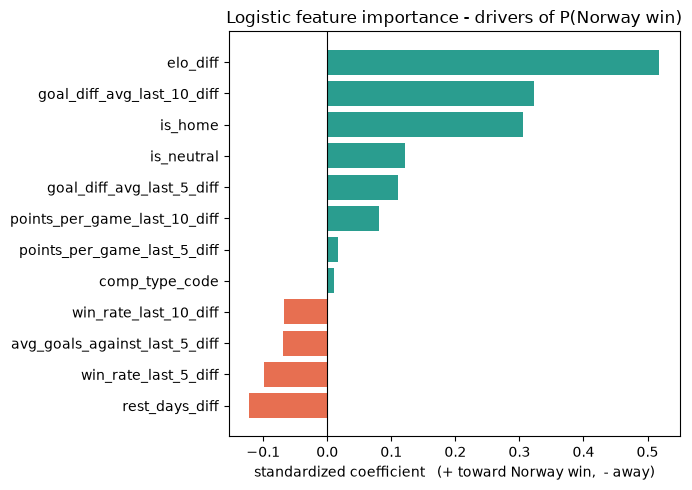

,draw,loss,win,importance
elo_diff,0.000,-0.519,0.519,0.346
goal_diff_avg_last_10_diff,0.000,-0.323,0.323,0.215
is_home,-0.000,-0.305,0.305,0.203
is_neutral,0.064,-0.185,0.121,0.123
rest_days_diff,-0.002,0.124,-0.122,0.082
goal_diff_avg_last_5_diff,0.000,-0.111,0.111,0.074
win_rate_last_5_diff,0.001,0.098,-0.099,0.066
points_per_game_last_10_diff,0.001,-0.081,0.081,0.054
win_rate_last_10_diff,-0.001,0.069,-0.068,0.046
avg_goals_against_last_5_diff,0.001,0.068,-0.069,0.046


In [9]:
import matplotlib.pyplot as plt

# The logistic pipeline standardizes its inputs, so coefficient size = importance.
clf = model.named_steps["clf"]
classes = list(clf.classes_)                        # ['draw', 'loss', 'win']
coef_df = pd.DataFrame(clf.coef_.T, index=feats, columns=classes)
coef_df["importance"] = coef_df[classes].abs().mean(axis=1)

# Standardized coefficients for the Norway-win class:
# bar length = importance, sign = direction.
win_coef = coef_df["win"].sort_values()
colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in win_coef.values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(win_coef.index, win_coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("standardized coefficient   (+ toward Norway win,  - away)")
ax.set_title("Logistic feature importance - drivers of P(Norway win)")
plt.tight_layout()
plt.show()

# Full per-class coefficients, ranked by overall importance (mean |coef|).
coef_df.sort_values("importance", ascending=False).round(3)

---

**How to read this.** Probabilities are directional, not certainties. Consistent
findings for this project: **Elo dominates** the signal, **draws are hard** to call
as the single most likely outcome (a known property of 3-class football models),
and the advanced Flashscore stats are descriptive only (they do not feed the
logistic or Poisson models). With matchday 1 in the books, Norway enter this game
off a 4–1 win and Senegal off a 1–3 loss — reflected in a wider Elo gap. The
sample is small — treat the numbers as a reasoned lean, not a guarantee.